In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\ishan\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
14,15628972,Male,18,82000,0
82,15709476,Male,20,49000,0
53,15671655,Female,35,23000,0
221,15663161,Male,35,91000,1
261,15680587,Male,36,144000,1


In [4]:
df.shape

(400, 5)

In [5]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [8]:
df=df.iloc[:, 2:]

In [9]:
df.sample(10)

,Age,EstimatedSalary,Purchased
315,39,75000,1
125,39,61000,0
228,40,72000,0
147,41,30000,0
166,22,55000,0
300,58,38000,1
93,29,28000,0
271,59,76000,1
100,27,88000,0
171,34,115000,0


In [10]:
df.duplicated().sum()

np.int64(33)

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
X = df.iloc[:,:2]
y = df.iloc[:, 2]

In [14]:
X.shape

(367, 2)

In [15]:
y.shape

(367,)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [17]:
X_train.shape, X_test.shape

((256, 2), (111, 2))

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

scaler.fit(X_train)

StandardScaler()

In [20]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
X_train

,Age,EstimatedSalary
244,41,72000
164,33,69000
19,48,29000
154,40,47000
82,20,49000
...,...,...
73,33,113000
111,37,71000
288,41,79000
377,42,53000


In [22]:
X_train_scaled

array([[ 0.3682144 ,  0.03221994],
       [-0.39273726, -0.05252292],
       [ 1.03404711, -1.18242772],
       [ 0.27309544, -0.67397056],
       [-1.62928371, -0.61747532],
       [ 1.31940398,  2.12254382],
       [ 0.84380919, -1.21067534],
       [ 1.98523668, -0.92819914],
       [ 0.08285753,  0.2582009 ],
       [-0.01226143,  1.86831524],
       [-0.20249934, -0.50448484],
       [-1.53416475, -1.54964678],
       [-0.67809413, -0.61747532],
       [ 0.46333336, -0.47623722],
       [-0.86833205, -1.09768486],
       [ 0.17797649,  0.17345804],
       [-0.01226143, -0.25025626],
       [-0.48785622,  0.8231533 ],
       [-0.58297517, -1.04118962],
       [-1.05856996, -1.54964678],
       [-1.15368892,  0.45593424],
       [-0.20249934,  0.1169628 ],
       [-0.58297517,  0.14521042],
       [-0.963451  ,  0.37119138],
       [ 1.41452294, -1.40840868],
       [ 0.17797649,  0.99263902],
       [-1.05856996,  0.2582009 ],
       [-1.34392683, -1.21067534],
       [-1.05856996,

In [23]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [24]:
X_train_scaled

,Age,EstimatedSalary
0,0.368214,0.032220
1,-0.392737,-0.052523
2,1.034047,-1.182428
3,0.273095,-0.673971
4,-1.629284,-0.617475
...,...,...
251,-0.392737,1.190372
252,-0.012261,0.003972
253,0.368214,0.229953
254,0.463333,-0.504485


In [25]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,256.0,256.0
mean,37.1,70859.4
std,10.5,35470.6
min,18.0,15000.0
25%,29.0,43000.0
50%,36.0,70000.0
75%,45.2,88250.0
max,60.0,150000.0


In [26]:
np.round(X_train_scaled.describe(),3)

,Age,EstimatedSalary
count,256.000,256.000
mean,0.000,0.000
std,1.002,1.002
min,-1.820,-1.578
25%,-0.773,-0.787
50%,-0.107,-0.024
75%,0.772,0.491
max,2.175,2.236


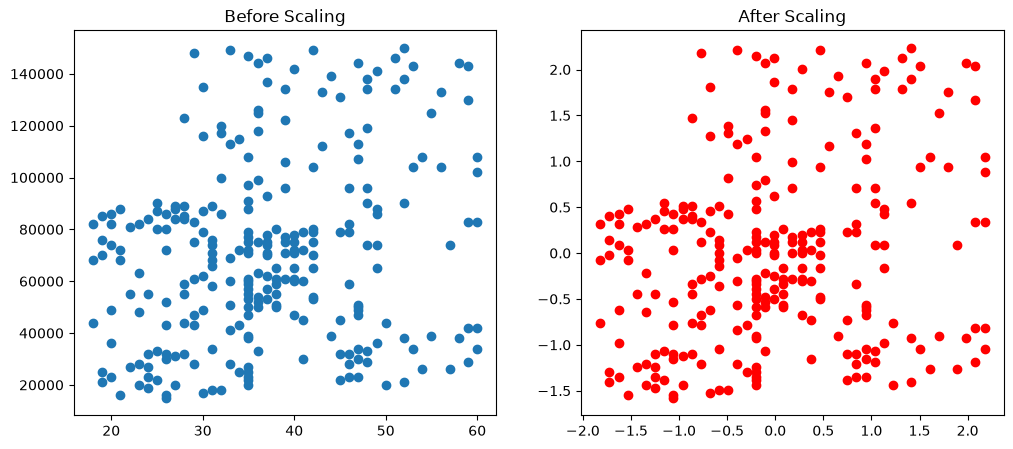

In [27]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')
plt.show()

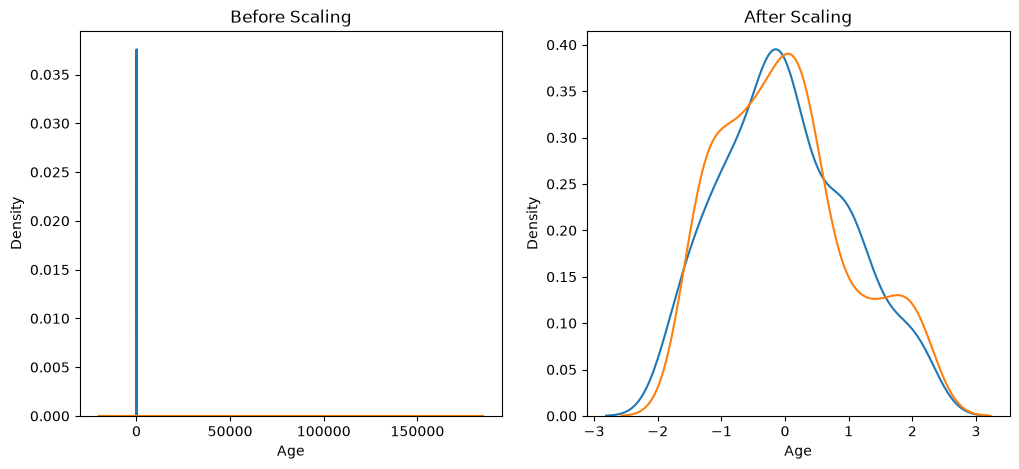

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)


ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

plt.show()


In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [31]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [32]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [33]:
from sklearn.metrics import accuracy_score

print('Actual\t', accuracy_score(y_test,y_pred))
print('Scaled\t', accuracy_score(y_test,y_pred_scaled))

Actual	 0.8198198198198198
Scaled	 0.8288288288288288


In [34]:
df.describe()

,Age,EstimatedSalary,Purchased
count,367.000000,367.000000,367.000000
mean,37.722071,70719.346049,0.376022
std,10.681383,34772.173908,0.485047
min,18.000000,15000.000000,0.000000
25%,29.500000,43000.000000,0.000000
50%,37.000000,71000.000000,0.000000
75%,46.000000,89000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [37]:
df1 = pd.DataFrame({'Age':[5,90,95], 'EstimatedSalary':[1000, 250000, 350000], 'Purchased': [0,1,1]})

df = pd.concat([df,df1],ignore_index=True)

In [38]:
df.shape

(370, 3)

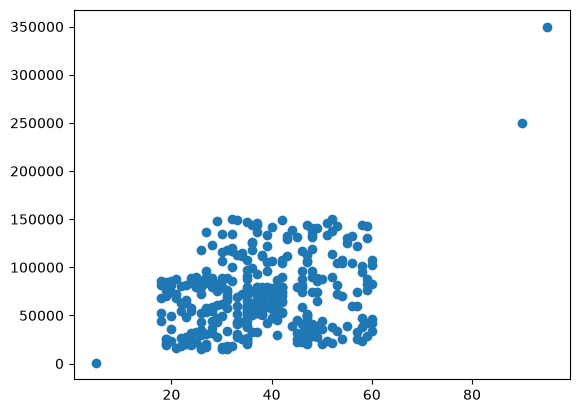

In [39]:
plt.scatter(df['Age'],df['EstimatedSalary'])